In [76]:
import numpy as np
import pandas as pd

%matplotlib widget
import matplotlib.pyplot as plt
import mplcursors

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [77]:
DATA_DIR = Path("/home/rauls/Desktop/VirgoBRET/cut_parquet_data")
PARQUET_FILES = sorted(DATA_DIR.glob("**/jan/qtransform_features.parquet"))

RANDOM_STATE = 42

if len(PARQUET_FILES) == 0:
    raise FileNotFoundError(
        f"No parquet files found inside: {DATA_DIR}"
    )

print(f"Found {len(PARQUET_FILES)} parquet files.")

dataframes = []

for file in PARQUET_FILES:
    print(f"Loading: {file}")
    df = pd.read_parquet(file)
    df["source_file"] = file.name
    df["source_path"] = str(file)

    dataframes.append(df)

df_all = pd.concat(dataframes,ignore_index=True)

feature_columns = [col for col in df_all.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df_all[feature_columns].to_numpy(dtype=np.float64)

print("Feature matrix:")
print(f"X.shape = {X.shape}")

Found 4 parquet files.
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jan/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2023/jan/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2024/jan/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2025/jan/qtransform_features.parquet
Number of features: 1230
Feature matrix:
X.shape = (3741, 1230)


Scaled matrix: (3741, 1230)
PCA components: 2
Explained variance: 0.1778


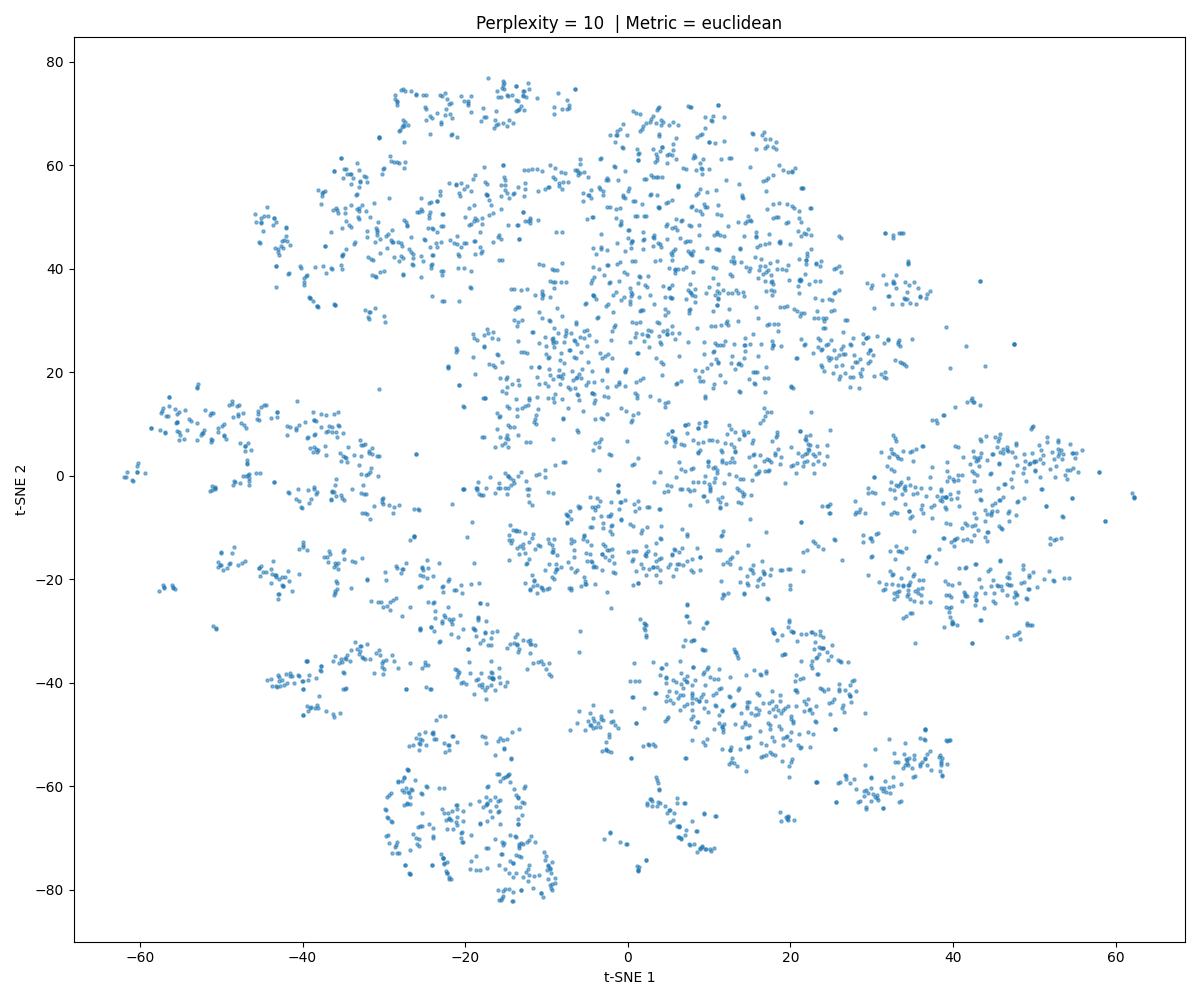

In [78]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled matrix: {X_scaled.shape}") 

PCA_COMPONENTS = 2

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=10,early_exaggeration=50,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0],X_tsne[:, 1],s=5,alpha=0.5)

cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_hover(sel):
    sel.annotation.set_text(f"Index: {sel.index}")

plt.title(f"Perplexity = 10  | Metric = euclidean")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
    
plt.tight_layout()
plt.show()

In [79]:
DATA_DIR = Path("/home/rauls/Desktop/VirgoBRET/cut_parquet_data")
PARQUET_FILES = sorted(DATA_DIR.glob("**/feb/qtransform_features.parquet"))

if len(PARQUET_FILES) == 0:
    raise FileNotFoundError(
        f"No parquet files found inside: {DATA_DIR}"
    )

print(f"Found {len(PARQUET_FILES)} parquet files.")

dataframes = []

for file in PARQUET_FILES:
    print(f"Loading: {file}")
    df = pd.read_parquet(file)
    df["source_file"] = file.name
    df["source_path"] = str(file)

    dataframes.append(df)

df_all = pd.concat(dataframes,ignore_index=True)

feature_columns = [col for col in df_all.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df_all[feature_columns].to_numpy(dtype=np.float64)

print("Feature matrix:")
print(f"X.shape = {X.shape}")

Found 4 parquet files.
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/feb/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2023/feb/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2024/feb/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2025/feb/qtransform_features.parquet
Number of features: 1230
Feature matrix:
X.shape = (1492, 1230)


Scaled matrix: (1492, 1230)
PCA components: 2
Explained variance: 0.1938


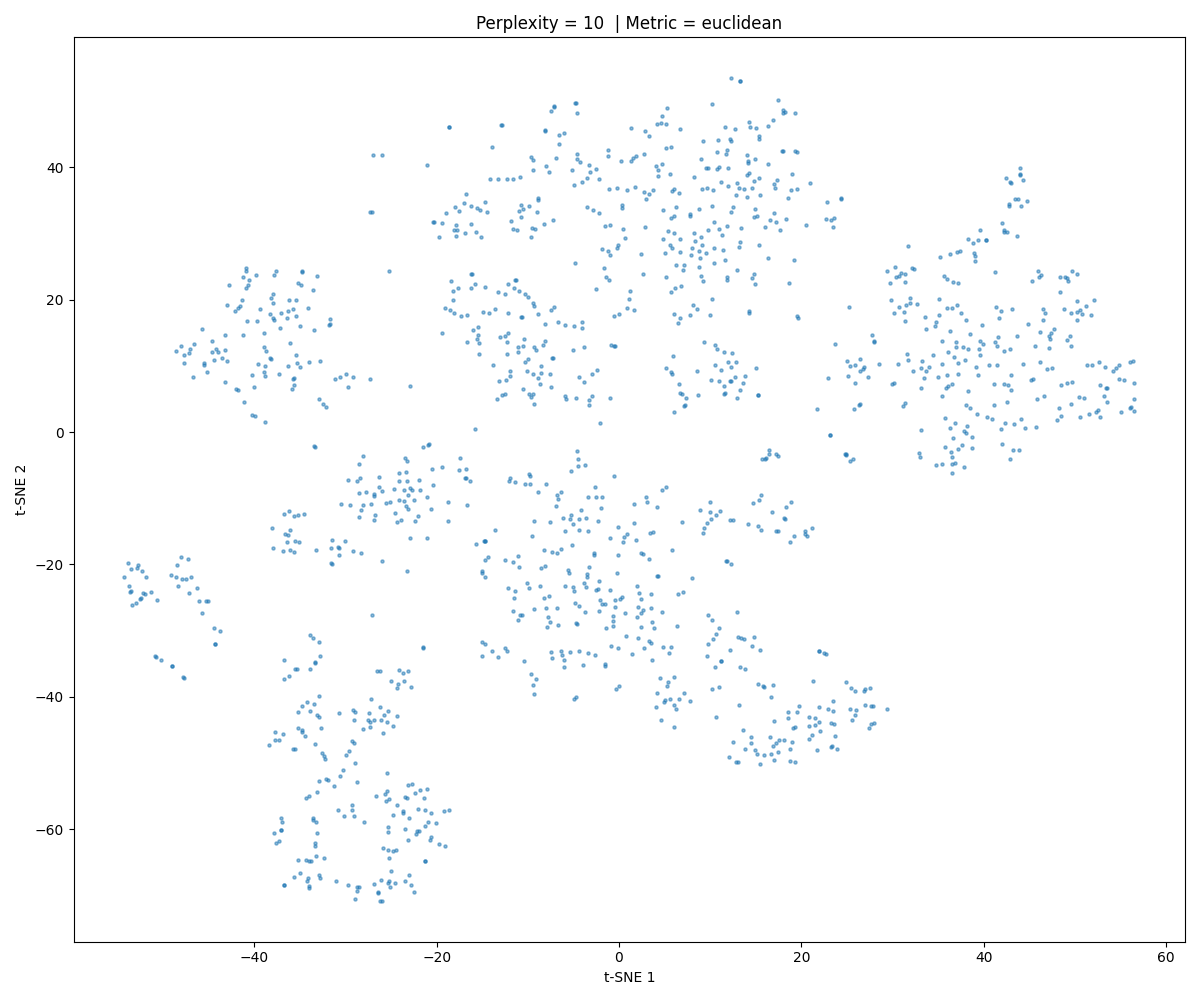

In [80]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled matrix: {X_scaled.shape}") 

PCA_COMPONENTS = 2

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=10,early_exaggeration=50,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0],X_tsne[:, 1],s=5,alpha=0.5)

cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_hover(sel):
    sel.annotation.set_text(f"Index: {sel.index}")

plt.title(f"Perplexity = 10  | Metric = euclidean")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
    
plt.tight_layout()
plt.show()

In [81]:
DATA_DIR = Path("/home/rauls/Desktop/VirgoBRET/cut_parquet_data")
PARQUET_FILES = sorted(DATA_DIR.glob("**/mar/qtransform_features.parquet"))

if len(PARQUET_FILES) == 0:
    raise FileNotFoundError(
        f"No parquet files found inside: {DATA_DIR}"
    )

print(f"Found {len(PARQUET_FILES)} parquet files.")

dataframes = []

for file in PARQUET_FILES:
    print(f"Loading: {file}")
    df = pd.read_parquet(file)
    df["source_file"] = file.name
    df["source_path"] = str(file)

    dataframes.append(df)

df_all = pd.concat(dataframes,ignore_index=True)

feature_columns = [col for col in df_all.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df_all[feature_columns].to_numpy(dtype=np.float64)

print("Feature matrix:")
print(f"X.shape = {X.shape}")

Found 4 parquet files.
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/mar/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2023/mar/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2024/mar/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2025/mar/qtransform_features.parquet
Number of features: 1230
Feature matrix:
X.shape = (2260, 1230)


Scaled matrix: (2260, 1230)
PCA components: 2
Explained variance: 0.1753


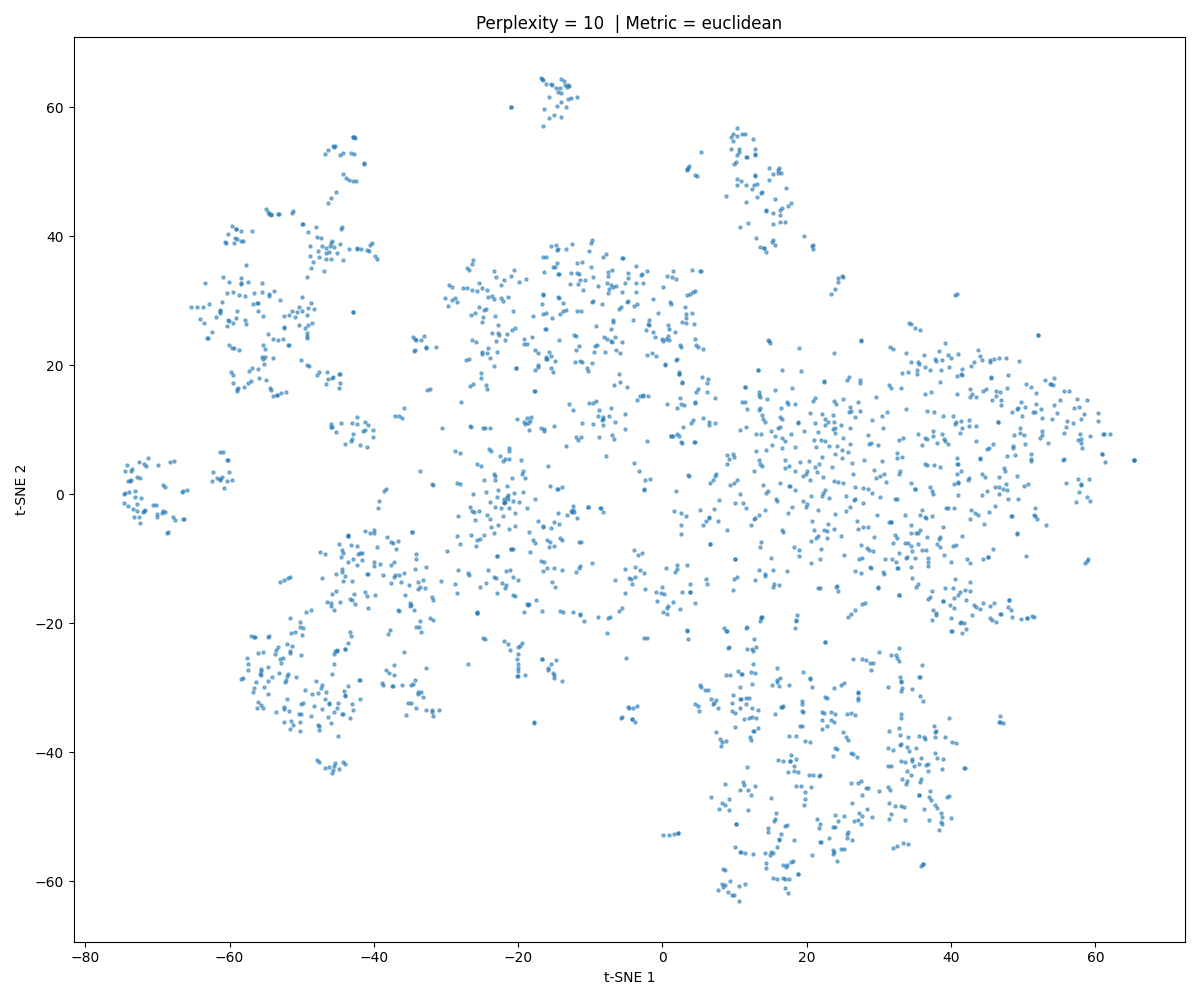

In [82]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled matrix: {X_scaled.shape}") 

PCA_COMPONENTS = 2

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=10,early_exaggeration=50,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0],X_tsne[:, 1],s=5,alpha=0.5)

cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_hover(sel):
    sel.annotation.set_text(f"Index: {sel.index}")

plt.title(f"Perplexity = 10  | Metric = euclidean")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
    
plt.tight_layout()
plt.show()

In [83]:
DATA_DIR = Path("/home/rauls/Desktop/VirgoBRET/cut_parquet_data")
PARQUET_FILES = sorted(DATA_DIR.glob("**/apr/qtransform_features.parquet"))

if len(PARQUET_FILES) == 0:
    raise FileNotFoundError(
        f"No parquet files found inside: {DATA_DIR}"
    )

print(f"Found {len(PARQUET_FILES)} parquet files.")

dataframes = []

for file in PARQUET_FILES:
    print(f"Loading: {file}")
    df = pd.read_parquet(file)
    df["source_file"] = file.name
    df["source_path"] = str(file)

    dataframes.append(df)

df_all = pd.concat(dataframes,ignore_index=True)

feature_columns = [col for col in df_all.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df_all[feature_columns].to_numpy(dtype=np.float64)

print("Feature matrix:")
print(f"X.shape = {X.shape}")

Found 4 parquet files.
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/apr/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2023/apr/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2024/apr/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2025/apr/qtransform_features.parquet
Number of features: 1230
Feature matrix:
X.shape = (2249, 1230)


Scaled matrix: (2249, 1230)
PCA components: 2
Explained variance: 0.1629


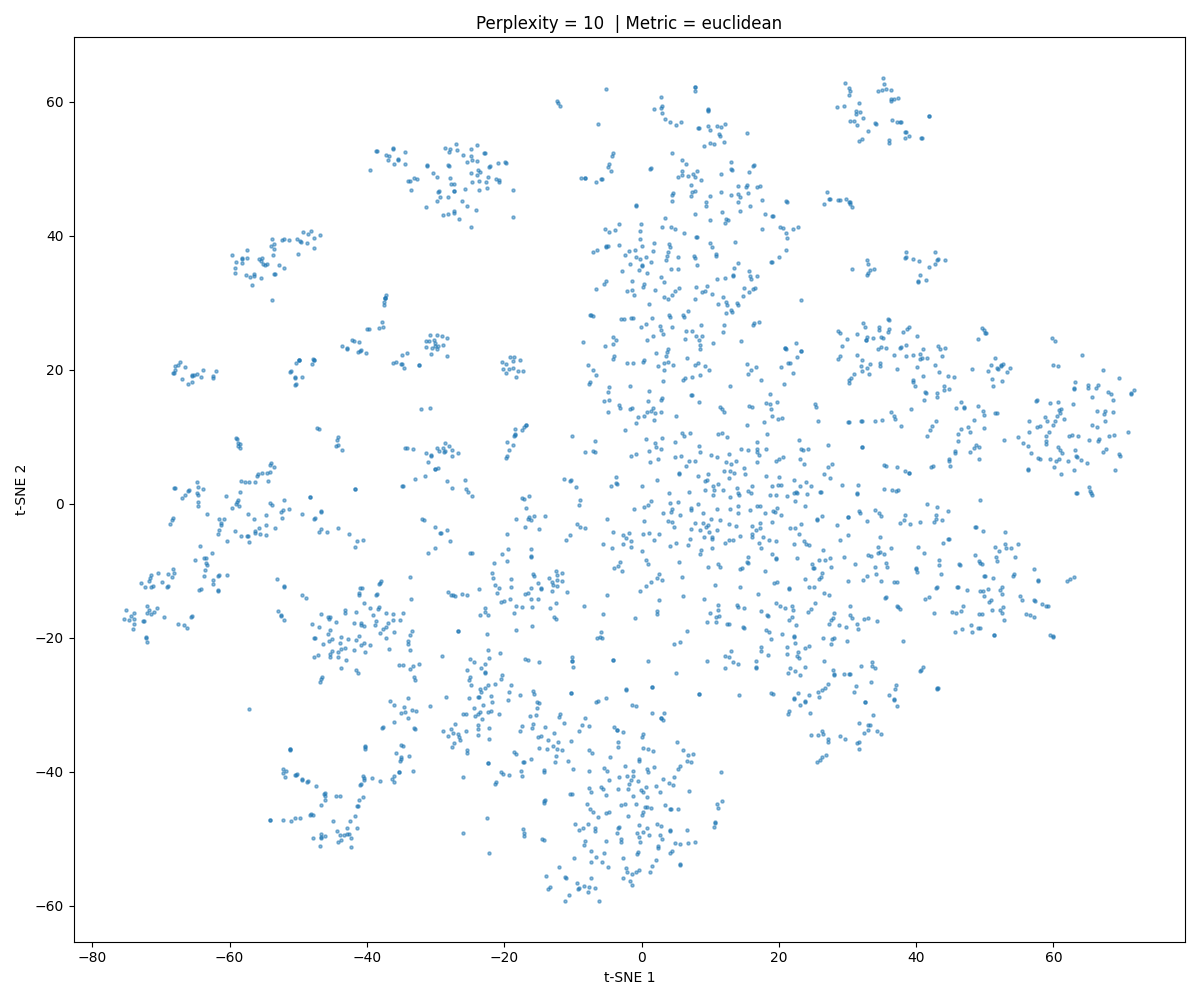

In [84]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled matrix: {X_scaled.shape}") 

PCA_COMPONENTS = 2

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=10,early_exaggeration=50,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0],X_tsne[:, 1],s=5,alpha=0.5)

cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_hover(sel):
    sel.annotation.set_text(f"Index: {sel.index}")

plt.title(f"Perplexity = 10  | Metric = euclidean")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
    
plt.tight_layout()
plt.show()

In [85]:
DATA_DIR = Path("/home/rauls/Desktop/VirgoBRET/cut_parquet_data")
PARQUET_FILES = sorted(DATA_DIR.glob("**/may/qtransform_features.parquet"))

if len(PARQUET_FILES) == 0:
    raise FileNotFoundError(
        f"No parquet files found inside: {DATA_DIR}"
    )

print(f"Found {len(PARQUET_FILES)} parquet files.")

dataframes = []

for file in PARQUET_FILES:
    print(f"Loading: {file}")
    df = pd.read_parquet(file)
    df["source_file"] = file.name
    df["source_path"] = str(file)

    dataframes.append(df)

df_all = pd.concat(dataframes,ignore_index=True)

feature_columns = [col for col in df_all.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df_all[feature_columns].to_numpy(dtype=np.float64)

print("Feature matrix:")
print(f"X.shape = {X.shape}")

Found 4 parquet files.
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/may/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2023/may/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2024/may/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2025/may/qtransform_features.parquet
Number of features: 1230
Feature matrix:
X.shape = (3485, 1230)


Scaled matrix: (3485, 1230)
PCA components: 2
Explained variance: 0.1714


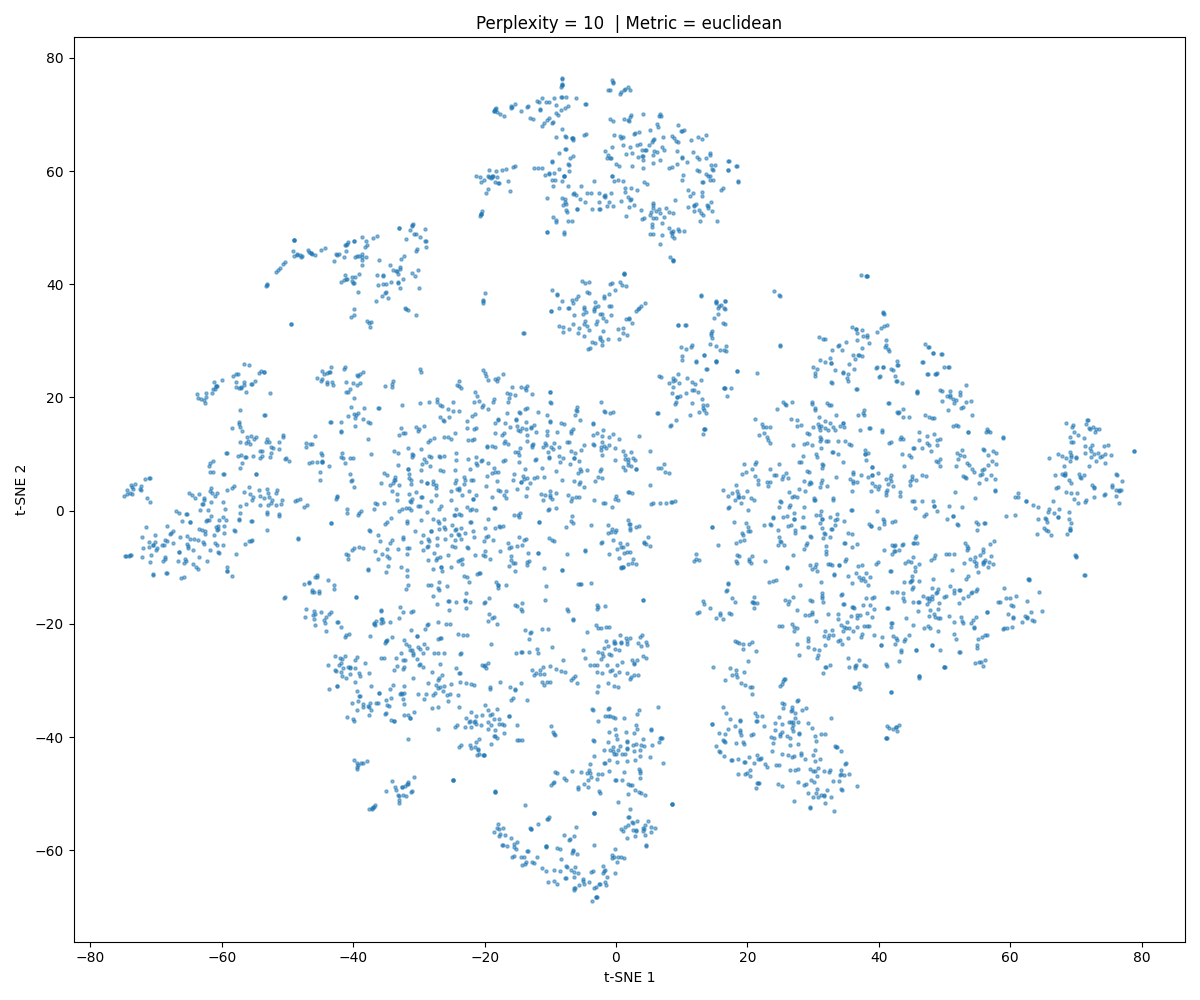

In [86]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled matrix: {X_scaled.shape}") 

PCA_COMPONENTS = 2

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=10,early_exaggeration=50,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0],X_tsne[:, 1],s=5,alpha=0.5)

cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_hover(sel):
    sel.annotation.set_text(f"Index: {sel.index}")

plt.title(f"Perplexity = 10  | Metric = euclidean")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
    
plt.tight_layout()
plt.show()

In [87]:
DATA_DIR = Path("/home/rauls/Desktop/VirgoBRET/cut_parquet_data")
PARQUET_FILES = sorted(DATA_DIR.glob("**/jun/qtransform_features.parquet"))

if len(PARQUET_FILES) == 0:
    raise FileNotFoundError(
        f"No parquet files found inside: {DATA_DIR}"
    )

print(f"Found {len(PARQUET_FILES)} parquet files.")

dataframes = []

for file in PARQUET_FILES:
    print(f"Loading: {file}")
    df = pd.read_parquet(file)
    df["source_file"] = file.name
    df["source_path"] = str(file)

    dataframes.append(df)

df_all = pd.concat(dataframes,ignore_index=True)

feature_columns = [col for col in df_all.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df_all[feature_columns].to_numpy(dtype=np.float64)

print("Feature matrix:")
print(f"X.shape = {X.shape}")

Found 4 parquet files.
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jun/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2023/jun/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2024/jun/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2025/jun/qtransform_features.parquet
Number of features: 1230
Feature matrix:
X.shape = (4734, 1230)


Scaled matrix: (4734, 1230)
PCA components: 2
Explained variance: 0.1549


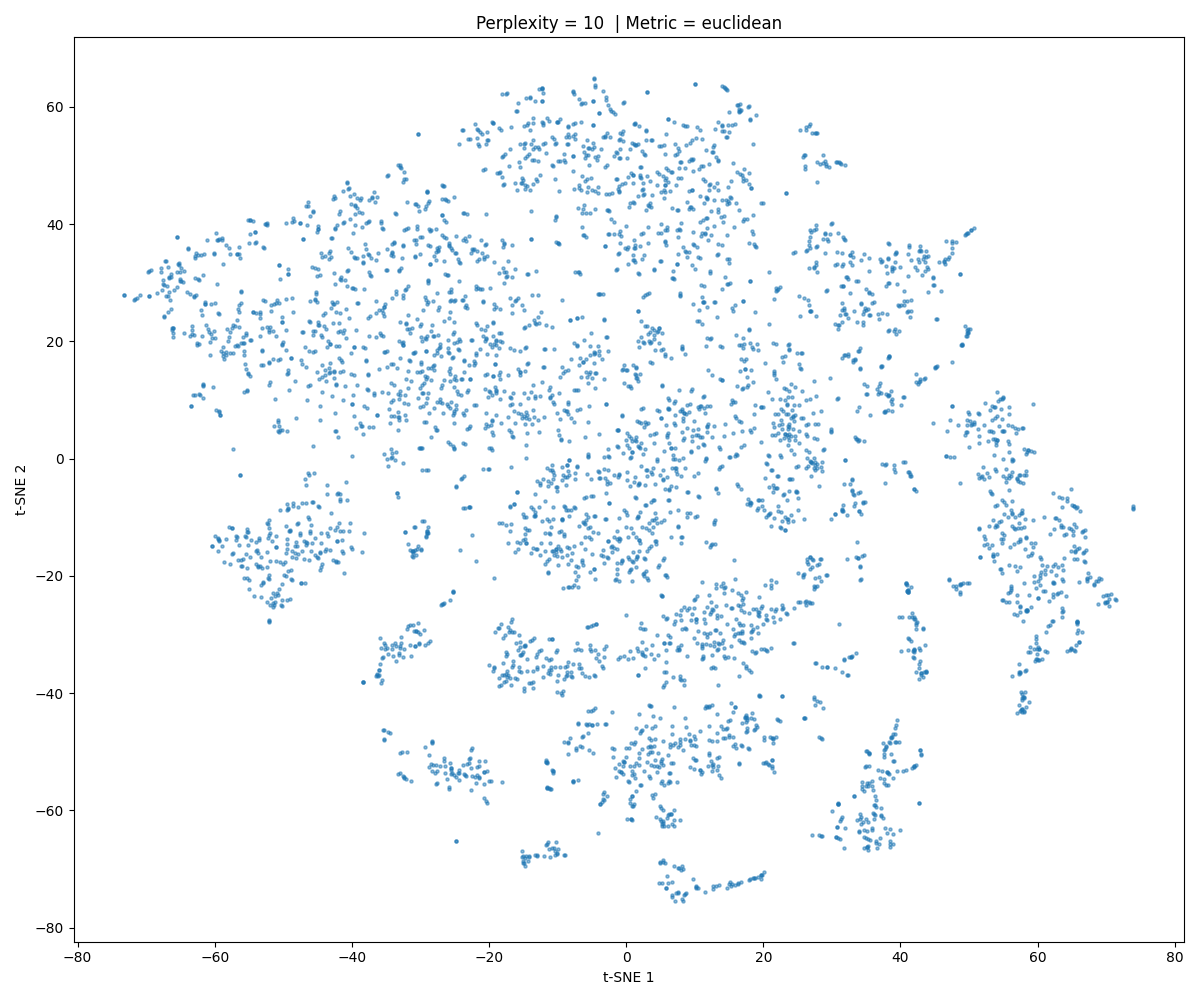

In [88]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled matrix: {X_scaled.shape}") 

PCA_COMPONENTS = 2

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=10,early_exaggeration=50,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0],X_tsne[:, 1],s=5,alpha=0.5)

cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_hover(sel):
    sel.annotation.set_text(f"Index: {sel.index}")

plt.title(f"Perplexity = 10  | Metric = euclidean")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
    
plt.tight_layout()
plt.show()

In [89]:
DATA_DIR = Path("/home/rauls/Desktop/VirgoBRET/cut_parquet_data")
PARQUET_FILES = sorted(DATA_DIR.glob("**/jul/qtransform_features.parquet"))

if len(PARQUET_FILES) == 0:
    raise FileNotFoundError(
        f"No parquet files found inside: {DATA_DIR}"
    )

print(f"Found {len(PARQUET_FILES)} parquet files.")

dataframes = []

for file in PARQUET_FILES:
    print(f"Loading: {file}")
    df = pd.read_parquet(file)
    df["source_file"] = file.name
    df["source_path"] = str(file)

    dataframes.append(df)

df_all = pd.concat(dataframes,ignore_index=True)

feature_columns = [col for col in df_all.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df_all[feature_columns].to_numpy(dtype=np.float64)

print("Feature matrix:")
print(f"X.shape = {X.shape}")

Found 4 parquet files.
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jul/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2023/jul/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2024/jul/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2025/jul/qtransform_features.parquet
Number of features: 1230
Feature matrix:
X.shape = (2563, 1230)


Scaled matrix: (2563, 1230)
PCA components: 2
Explained variance: 0.1689


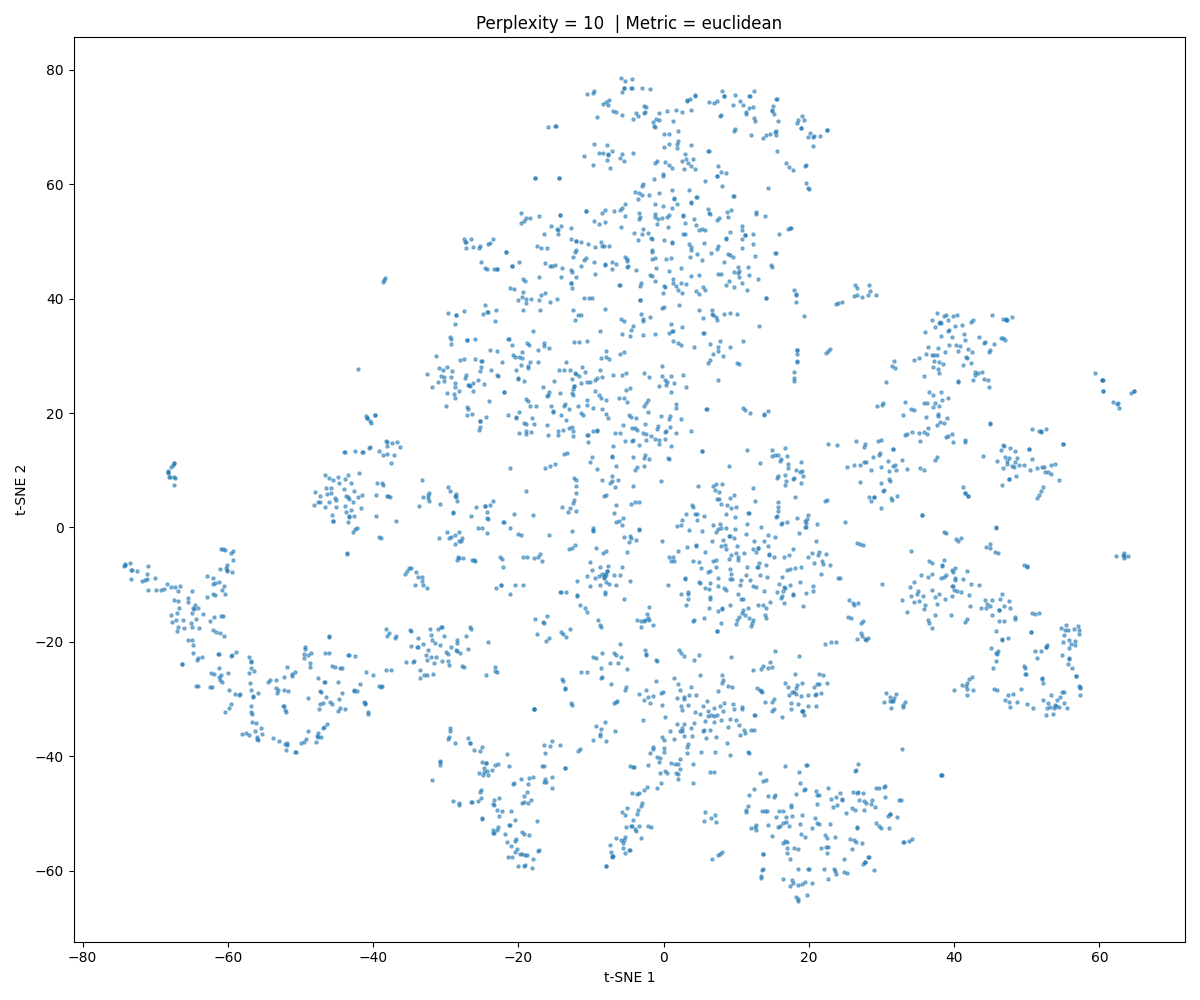

In [90]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled matrix: {X_scaled.shape}") 

PCA_COMPONENTS = 2

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=10,early_exaggeration=50,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0],X_tsne[:, 1],s=5,alpha=0.5)

cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_hover(sel):
    sel.annotation.set_text(f"Index: {sel.index}")

plt.title(f"Perplexity = 10  | Metric = euclidean")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
    
plt.tight_layout()
plt.show()

In [91]:
DATA_DIR = Path("/home/rauls/Desktop/VirgoBRET/cut_parquet_data")
PARQUET_FILES = sorted(DATA_DIR.glob("**/ago/qtransform_features.parquet"))

if len(PARQUET_FILES) == 0:
    raise FileNotFoundError(
        f"No parquet files found inside: {DATA_DIR}"
    )

print(f"Found {len(PARQUET_FILES)} parquet files.")

dataframes = []

for file in PARQUET_FILES:
    print(f"Loading: {file}")
    df = pd.read_parquet(file)
    df["source_file"] = file.name
    df["source_path"] = str(file)

    dataframes.append(df)

df_all = pd.concat(dataframes,ignore_index=True)

feature_columns = [col for col in df_all.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df_all[feature_columns].to_numpy(dtype=np.float64)

print("Feature matrix:")
print(f"X.shape = {X.shape}")

Found 4 parquet files.
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/ago/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2023/ago/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2024/ago/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2025/ago/qtransform_features.parquet
Number of features: 1230
Feature matrix:
X.shape = (1446, 1230)


Scaled matrix: (1446, 1230)
PCA components: 2
Explained variance: 0.1653


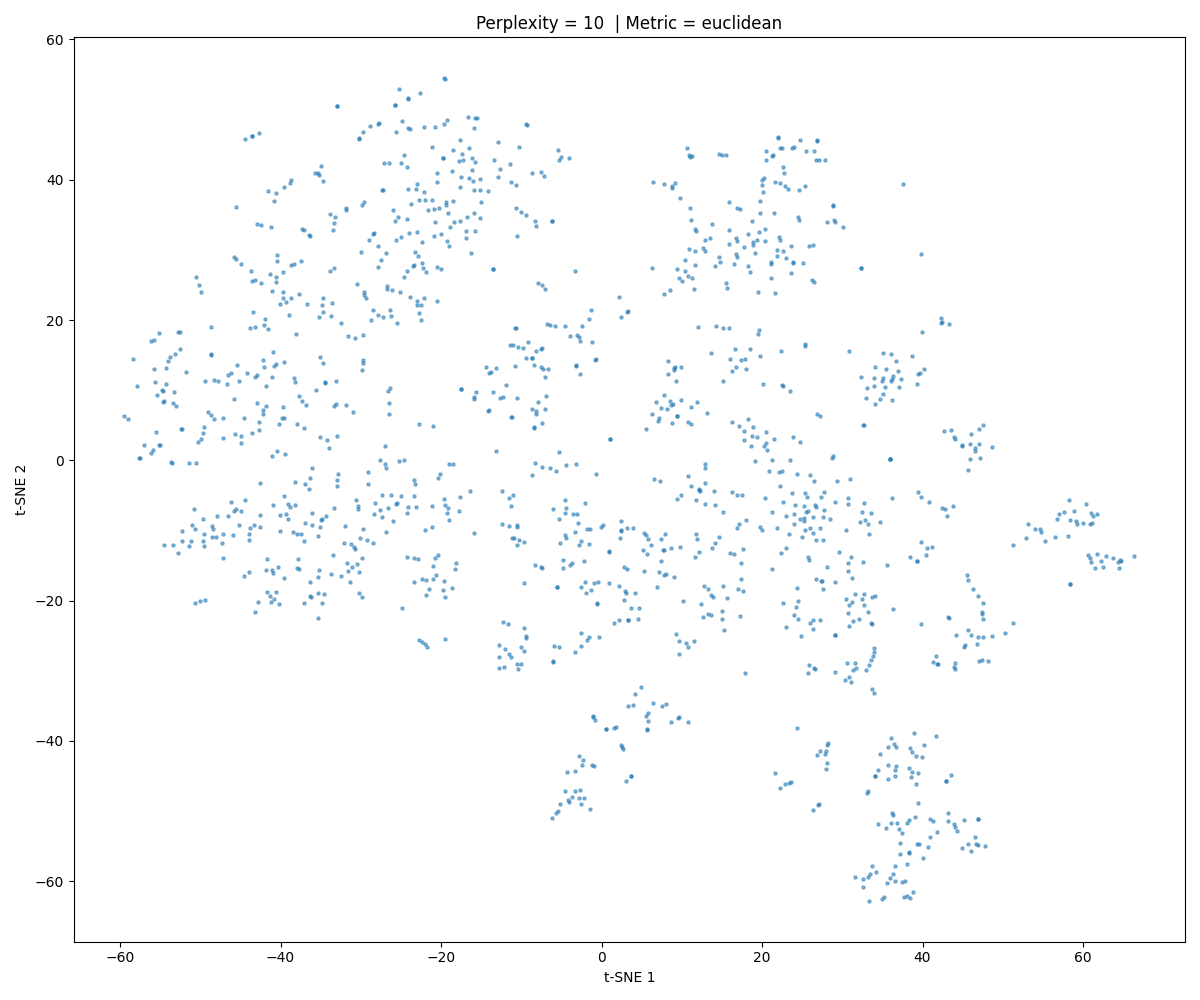

In [92]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled matrix: {X_scaled.shape}") 

PCA_COMPONENTS = 2

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=10,early_exaggeration=50,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0],X_tsne[:, 1],s=5,alpha=0.5)

cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_hover(sel):
    sel.annotation.set_text(f"Index: {sel.index}")

plt.title(f"Perplexity = 10  | Metric = euclidean")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
    
plt.tight_layout()
plt.show()

In [93]:
DATA_DIR = Path("/home/rauls/Desktop/VirgoBRET/cut_parquet_data")
PARQUET_FILES = sorted(DATA_DIR.glob("**/sep/qtransform_features.parquet"))

if len(PARQUET_FILES) == 0:
    raise FileNotFoundError(
        f"No parquet files found inside: {DATA_DIR}"
    )

print(f"Found {len(PARQUET_FILES)} parquet files.")

dataframes = []

for file in PARQUET_FILES:
    print(f"Loading: {file}")
    df = pd.read_parquet(file)
    df["source_file"] = file.name
    df["source_path"] = str(file)

    dataframes.append(df)

df_all = pd.concat(dataframes,ignore_index=True)

feature_columns = [col for col in df_all.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df_all[feature_columns].to_numpy(dtype=np.float64)

print("Feature matrix:")
print(f"X.shape = {X.shape}")

Found 4 parquet files.
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/sep/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2023/sep/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2024/sep/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2025/sep/qtransform_features.parquet
Number of features: 1230
Feature matrix:
X.shape = (1506, 1230)


Scaled matrix: (1506, 1230)
PCA components: 2
Explained variance: 0.1845


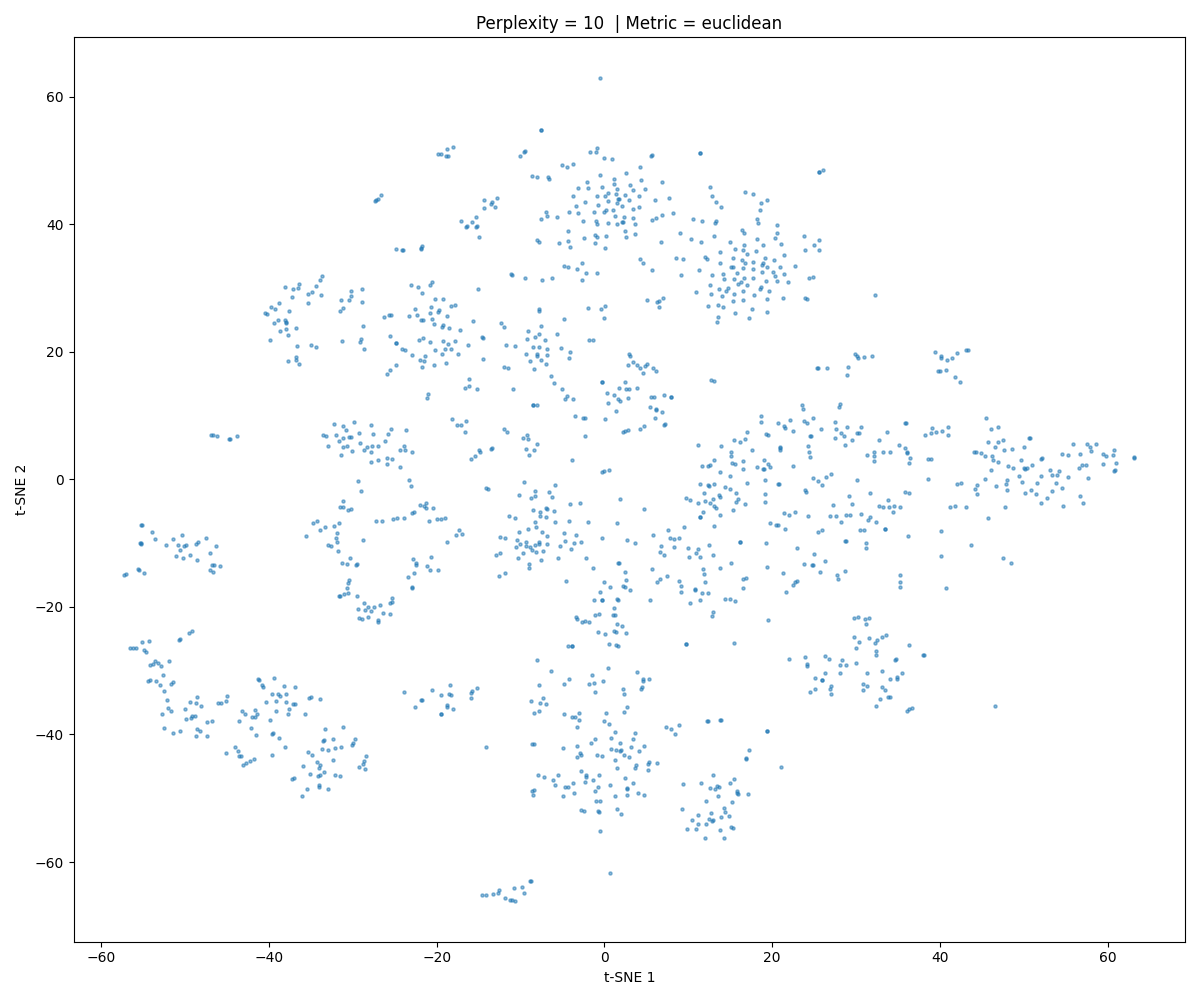

In [94]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled matrix: {X_scaled.shape}") 

PCA_COMPONENTS = 2

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=10,early_exaggeration=50,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0],X_tsne[:, 1],s=5,alpha=0.5)

cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_hover(sel):
    sel.annotation.set_text(f"Index: {sel.index}")

plt.title(f"Perplexity = 10  | Metric = euclidean")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
    
plt.tight_layout()
plt.show()

In [95]:
DATA_DIR = Path("/home/rauls/Desktop/VirgoBRET/cut_parquet_data")
PARQUET_FILES = sorted(DATA_DIR.glob("**/oct/qtransform_features.parquet"))

if len(PARQUET_FILES) == 0:
    raise FileNotFoundError(
        f"No parquet files found inside: {DATA_DIR}"
    )

print(f"Found {len(PARQUET_FILES)} parquet files.")

dataframes = []

for file in PARQUET_FILES:
    print(f"Loading: {file}")
    df = pd.read_parquet(file)
    df["source_file"] = file.name
    df["source_path"] = str(file)

    dataframes.append(df)

df_all = pd.concat(dataframes,ignore_index=True)

feature_columns = [col for col in df_all.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df_all[feature_columns].to_numpy(dtype=np.float64)

print("Feature matrix:")
print(f"X.shape = {X.shape}")

Found 4 parquet files.
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/oct/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2023/oct/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2024/oct/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2025/oct/qtransform_features.parquet
Number of features: 1230
Feature matrix:
X.shape = (1551, 1230)


Scaled matrix: (1551, 1230)
PCA components: 2
Explained variance: 0.1967


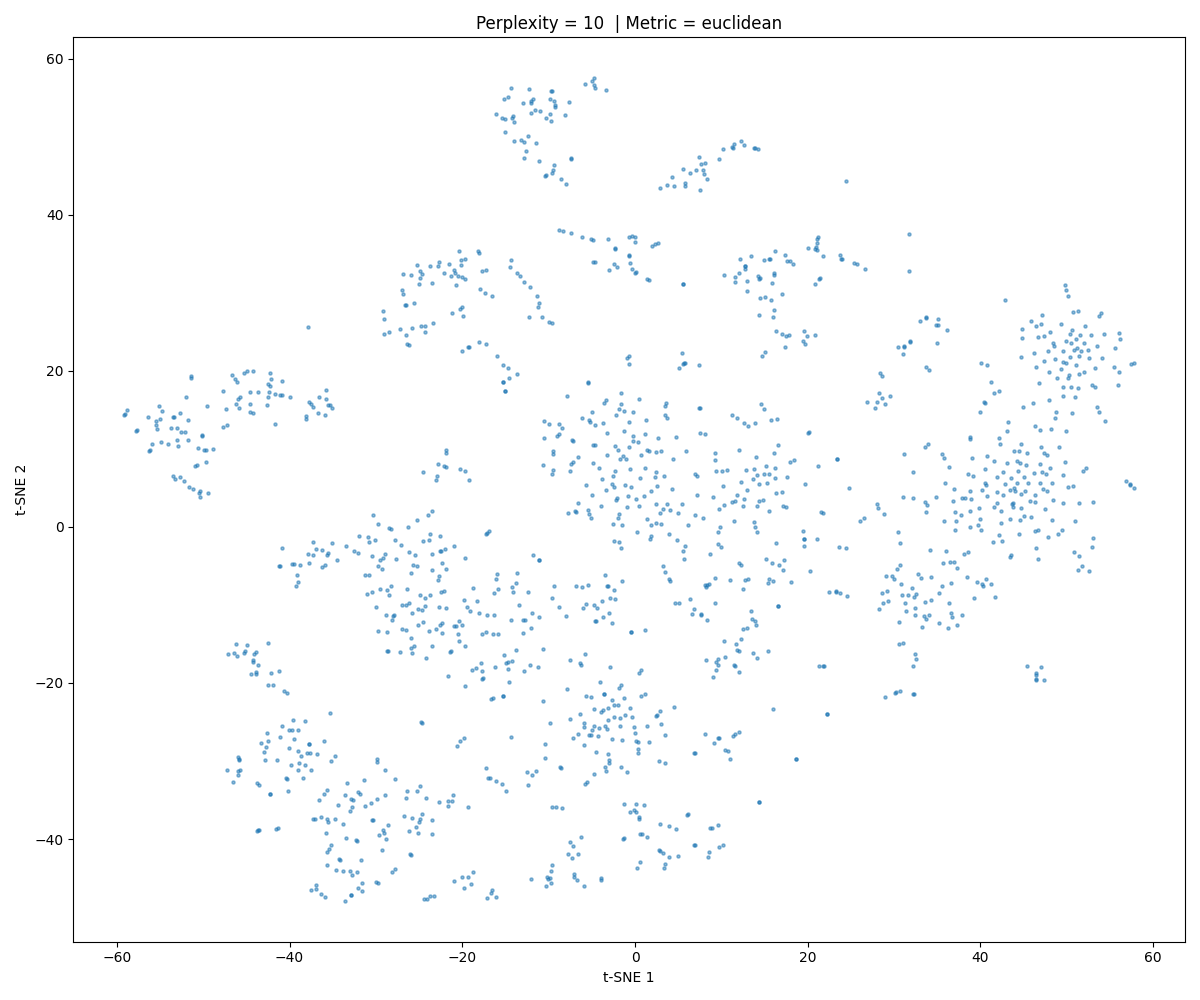

In [96]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled matrix: {X_scaled.shape}") 

PCA_COMPONENTS = 2

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=10,early_exaggeration=50,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0],X_tsne[:, 1],s=5,alpha=0.5)

cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_hover(sel):
    sel.annotation.set_text(f"Index: {sel.index}")

plt.title(f"Perplexity = 10  | Metric = euclidean")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
    
plt.tight_layout()
plt.show()

In [97]:
DATA_DIR = Path("/home/rauls/Desktop/VirgoBRET/cut_parquet_data")
PARQUET_FILES = sorted(DATA_DIR.glob("**/nov/qtransform_features.parquet"))

if len(PARQUET_FILES) == 0:
    raise FileNotFoundError(
        f"No parquet files found inside: {DATA_DIR}"
    )

print(f"Found {len(PARQUET_FILES)} parquet files.")

dataframes = []

for file in PARQUET_FILES:
    print(f"Loading: {file}")
    df = pd.read_parquet(file)
    df["source_file"] = file.name
    df["source_path"] = str(file)

    dataframes.append(df)

df_all = pd.concat(dataframes,ignore_index=True)

feature_columns = [col for col in df_all.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df_all[feature_columns].to_numpy(dtype=np.float64)

print("Feature matrix:")
print(f"X.shape = {X.shape}")

Found 4 parquet files.
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/nov/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2023/nov/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2024/nov/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2025/nov/qtransform_features.parquet
Number of features: 1230
Feature matrix:
X.shape = (3673, 1230)


Scaled matrix: (3673, 1230)
PCA components: 2
Explained variance: 0.1667


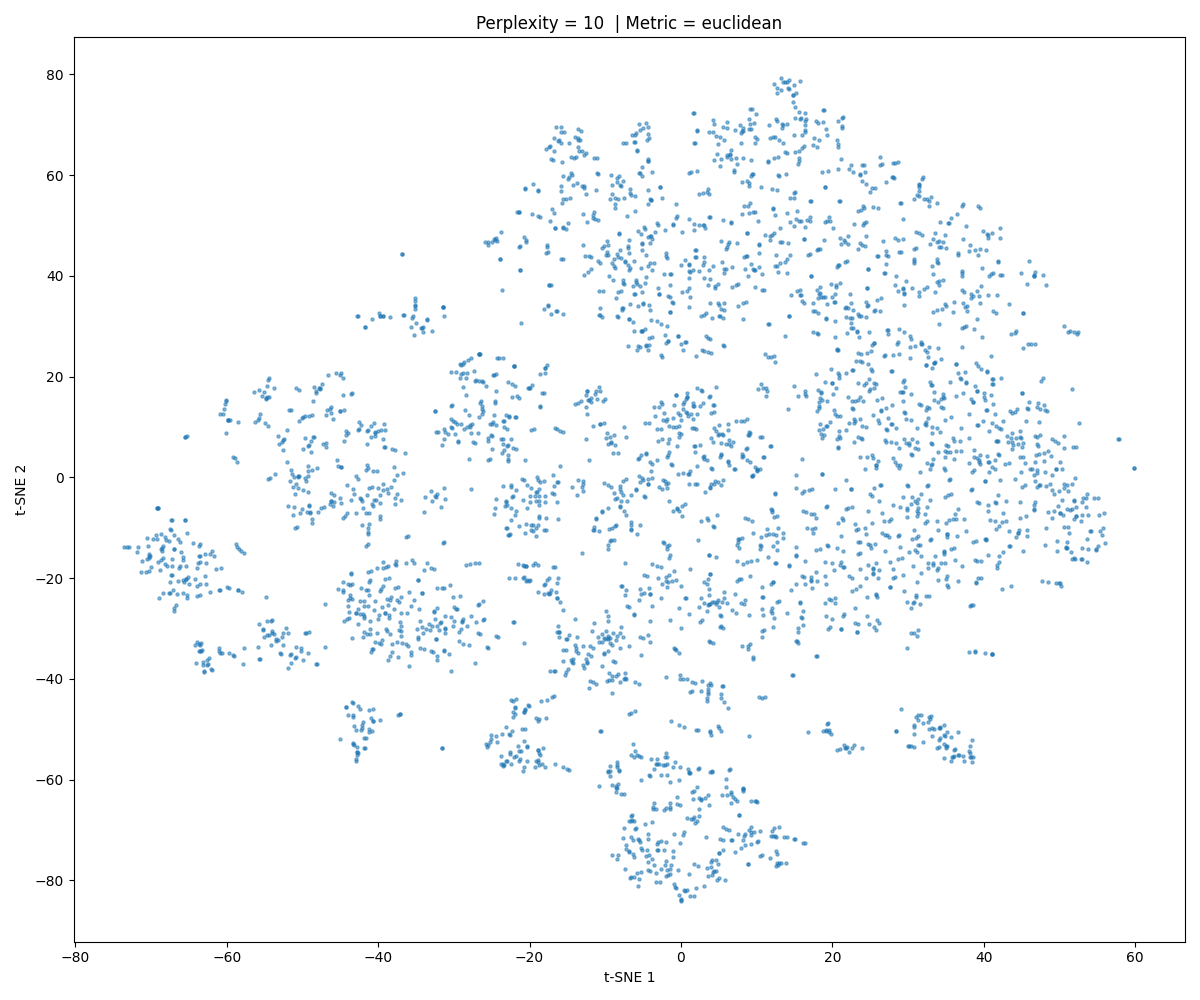

In [98]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled matrix: {X_scaled.shape}") 

PCA_COMPONENTS = 2

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=10,early_exaggeration=50,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0],X_tsne[:, 1],s=5,alpha=0.5)

cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_hover(sel):
    sel.annotation.set_text(f"Index: {sel.index}")

plt.title(f"Perplexity = 10  | Metric = euclidean")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
    
plt.tight_layout()
plt.show()

In [99]:
DATA_DIR = Path("/home/rauls/Desktop/VirgoBRET/cut_parquet_data")
PARQUET_FILES = sorted(DATA_DIR.glob("**/dec/qtransform_features.parquet"))

if len(PARQUET_FILES) == 0:
    raise FileNotFoundError(
        f"No parquet files found inside: {DATA_DIR}"
    )

print(f"Found {len(PARQUET_FILES)} parquet files.")

dataframes = []

for file in PARQUET_FILES:
    print(f"Loading: {file}")
    df = pd.read_parquet(file)
    df["source_file"] = file.name
    df["source_path"] = str(file)

    dataframes.append(df)

df_all = pd.concat(dataframes,ignore_index=True)

feature_columns = [col for col in df_all.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df_all[feature_columns].to_numpy(dtype=np.float64)

print("Feature matrix:")
print(f"X.shape = {X.shape}")

Found 4 parquet files.
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/dec/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2023/dec/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2024/dec/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2025/dec/qtransform_features.parquet
Number of features: 1230
Feature matrix:
X.shape = (2004, 1230)


Scaled matrix: (2004, 1230)
PCA components: 2
Explained variance: 0.1885


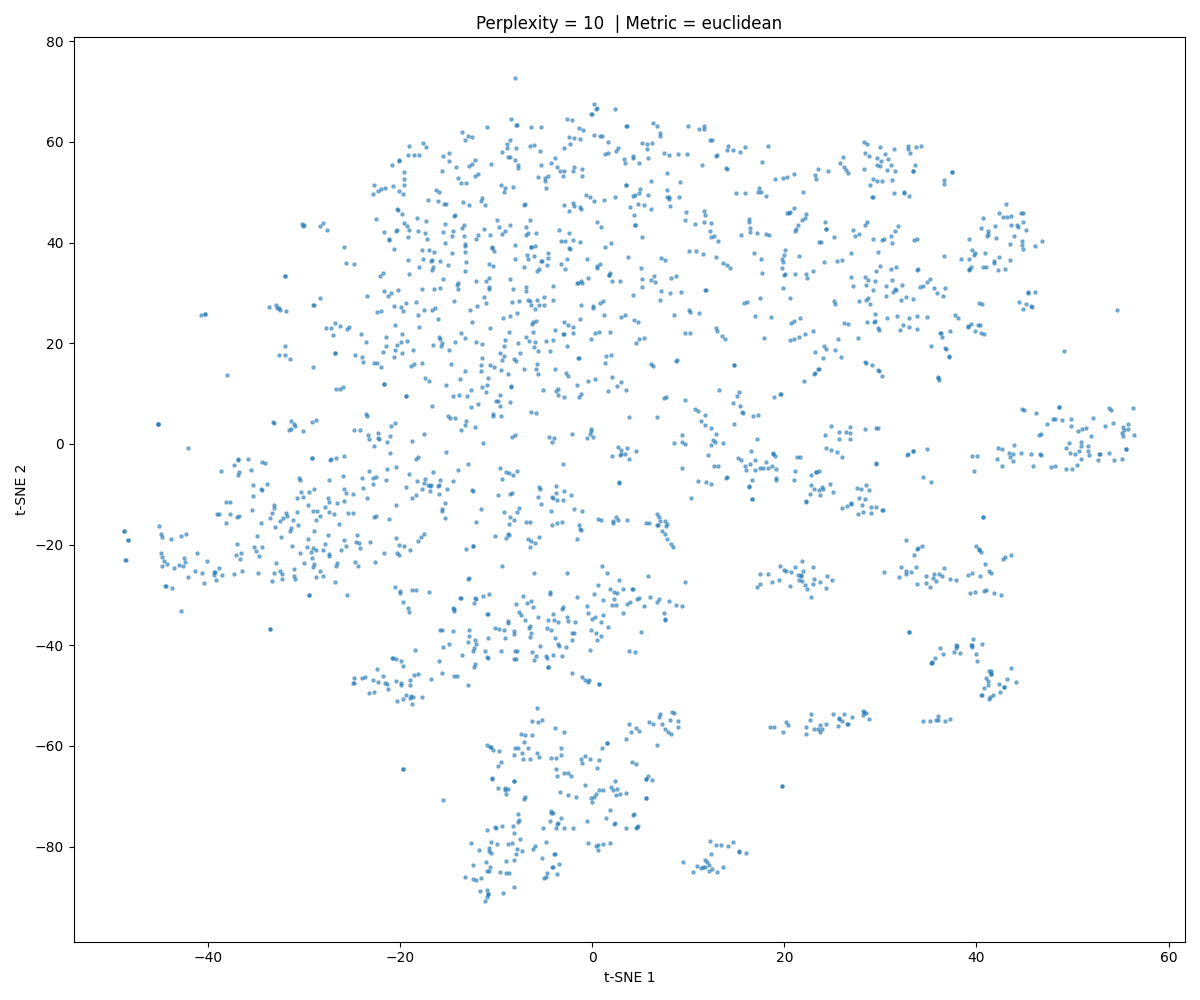

In [100]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled matrix: {X_scaled.shape}") 

PCA_COMPONENTS = 2

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=10,early_exaggeration=50,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0],X_tsne[:, 1],s=5,alpha=0.5)

cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_hover(sel):
    sel.annotation.set_text(f"Index: {sel.index}")

plt.title(f"Perplexity = 10  | Metric = euclidean")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
    
plt.tight_layout()
plt.show()